In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("imports done")

imports done


In [20]:
df = pd.read_csv('../data/heart.csv')
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['target'].value_counts())
df.head()

Shape: (1190, 12)

Target distribution:
target
1    629
0    561
Name: count, dtype: int64


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [21]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [22]:
print("Null values:\n", df.isnull().sum())


Null values:
 age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


### clean already 

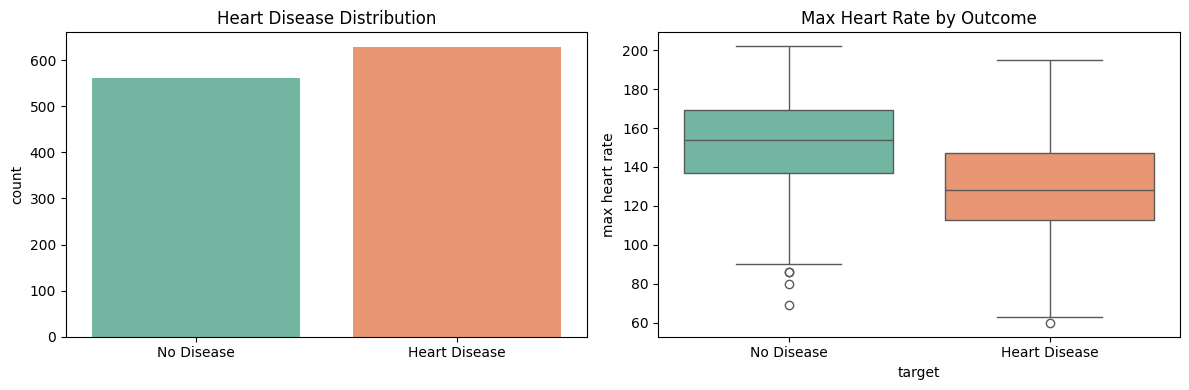

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='target', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Heart Disease Distribution')
axes[0].set_xticklabels(['No Disease', 'Heart Disease'])
axes[0].set_xlabel('')

sns.boxplot(x='target', y='max heart rate', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Max Heart Rate by Outcome')
axes[1].set_xticklabels(['No Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

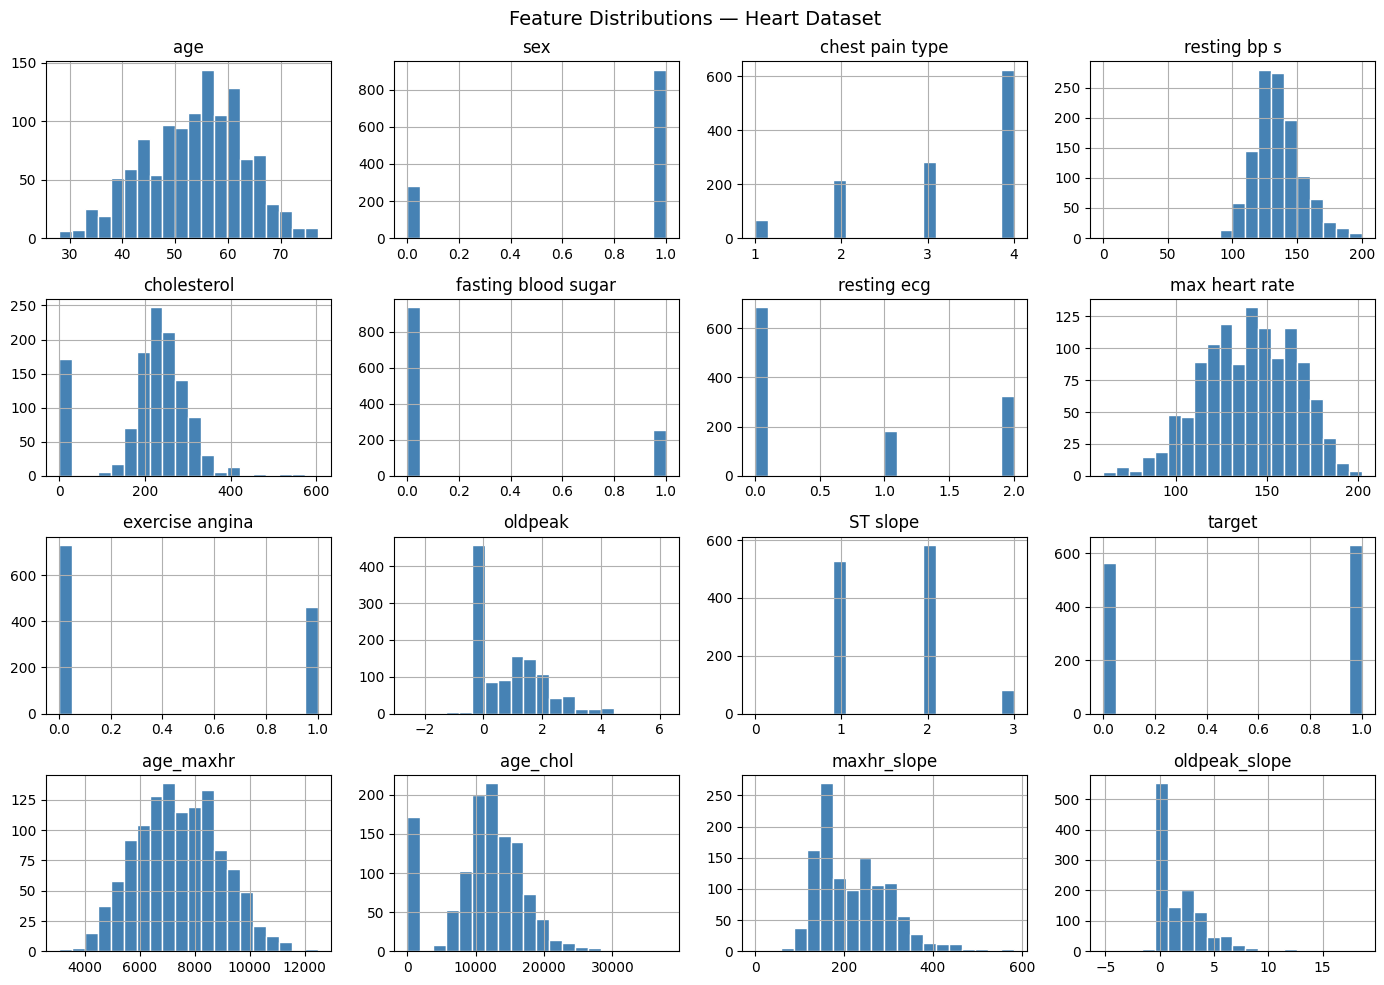

In [31]:
df.hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions — Heart Dataset', fontsize=14)
plt.tight_layout()
plt.show()

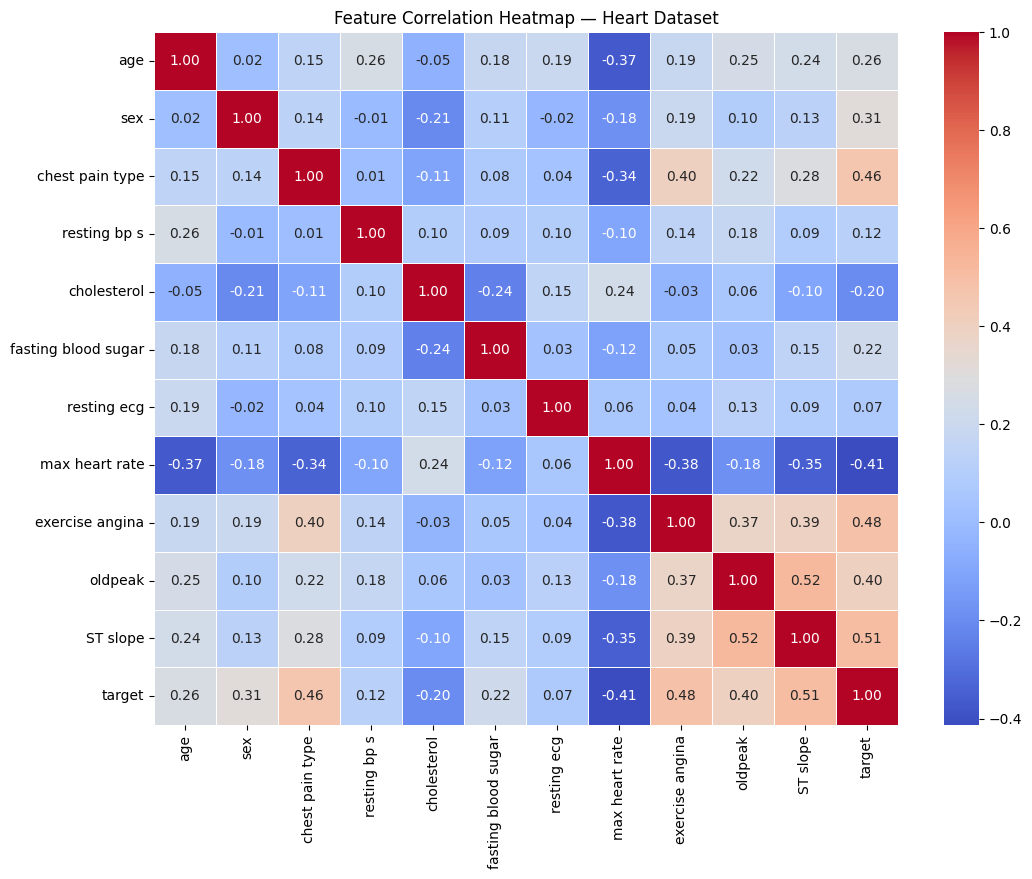

In [25]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap — Heart Dataset')
plt.show()

In [28]:
df['age_maxhr']      = df['age'] * df['max heart rate']
df['age_chol']       = df['age'] * df['cholesterol']
df['maxhr_slope']    = df['max heart rate'] * df['ST slope']
df['oldpeak_slope']  = df['oldpeak'] * df['ST slope']

print("New shape after feature engineering:", df.shape)
print("New features: age_maxhr, age_chol, maxhr_slope, oldpeak_slope")

New shape after feature engineering: (1190, 16)
New features: age_maxhr, age_chol, maxhr_slope, oldpeak_slope


In [32]:
X = df.drop('target', axis=1)
y = df['target']

print("Features:", X.shape)
print("Target:  ", y.shape)
print("\nAll feature columns:")
print(list(X.columns))

Features: (1190, 15)
Target:   (1190,)

All feature columns:
['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'age_maxhr', 'age_chol', 'maxhr_slope', 'oldpeak_slope']


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("features scaled")

features scaled


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"\nTrain outcome distribution:\n{y_train.value_counts()}")

Training samples: 952
Testing samples:  238

Train outcome distribution:
target
1    503
0    449
Name: count, dtype: int64


In [35]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE: ", dict(pd.Series(y_train_sm).value_counts()))
print("\nclass balance fixed")

Before SMOTE: {1: np.int64(503), 0: np.int64(449)}
After SMOTE:  {1: np.int64(503), 0: np.int64(503)}

class balance fixed


In [37]:

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)

print("\ngrid search complete")
print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits

grid search complete
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 score: 0.9095


In [38]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy*100:.2f}%\n")
print("Detailed Report:")
print(classification_report(y_test, predictions,
      target_names=['No Disease', 'Heart Disease']))

Accuracy: 92.44%

Detailed Report:
               precision    recall  f1-score   support

   No Disease       0.92      0.92      0.92       112
Heart Disease       0.93      0.93      0.93       126

     accuracy                           0.92       238
    macro avg       0.92      0.92      0.92       238
 weighted avg       0.92      0.92      0.92       238



## did smth went wrong?

## ok now good , not 100 accuracy or duplicates

Logistic Regression            → 85.29%
Random Forest (tuned)          → 92.44%
Gradient Boosting              → 89.50%
SVM                            → 88.24%


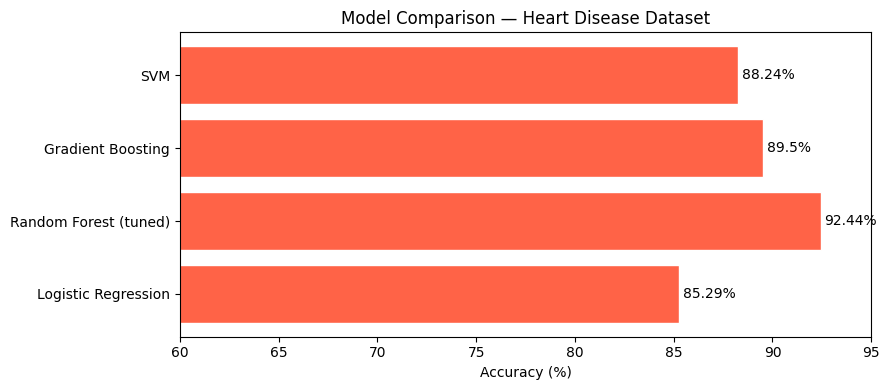

In [40]:
models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest (tuned)":best_model,
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM":                  SVC(kernel='rbf', class_weight='balanced')
}

results = {}
for name, m in models.items():
    if name != "Random Forest (tuned)":
        m.fit(X_train_sm, y_train_sm)
    acc = accuracy_score(y_test, m.predict(X_test))
    results[name] = round(acc * 100, 2)
    print(f"{name:30s} → {acc*100:.2f}%")

plt.figure(figsize=(9, 4))
plt.barh(list(results.keys()), list(results.values()),
         color='tomato', edgecolor='white')
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison — Heart Disease Dataset')
plt.xlim(60, 95)
for i, v in enumerate(results.values()):
    plt.text(v + 0.2, i, f"{v}%", va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [41]:
os.makedirs('../models', exist_ok=True)

final_model = best_model

joblib.dump(final_model, '../models/heart_model.pkl')
joblib.dump(scaler,      '../models/heart_scaler.pkl')

print("Model saved")
print("Scaler saved")
print(f"Features used:  {list(X.columns)}")

Model saved
Scaler saved
Features used:  ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'age_maxhr', 'age_chol', 'maxhr_slope', 'oldpeak_slope']
